# 04. Algerian Darija YouTube Corpus Statistics & Analysis

This notebook analyzes the unified dataset (`Data/youtube_corpus.jsonl`) generated from the cleaned, deduplicated YouTube comment collection pipeline.

### Metrics & Analyses Included:
1. **Corpus Volume**: Total rows (documents) and overall character count.
2. **Token Statistics**: Total word tokens, mean/std, min/max, median, and percentiles (25%, 50%, 75%, 90%, 95%, 99%).
3. **Script Distribution**: Token-level and document-level breakdown across **Arabic script**, **Latin script (Arabizi/French)**, **Mixed script**, and **Digits/Symbols/Emojis**.
4. **Visualizations**: Document length distribution, script composition breakdown, and top vocabulary tokens per script.


In [1]:
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from pathlib import Path

# Matplotlib & Plotting Style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

DATASET_PATH = Path("Data/youtube_corpus.jsonl") if Path("Data/youtube_corpus.jsonl").exists() else Path("../Data/youtube_corpus.jsonl")
print(f"Dataset path: {DATASET_PATH.resolve()} (exists: {DATASET_PATH.exists()})")


Dataset path: C:\Users\ASUS\Desktop\summer 2026\Darija\Data\youtube_corpus.jsonl (exists: True)


## 1. Fast Streaming & Token/Script Classification

We stream the documents from `Data/youtube_corpus.jsonl` and process:
- Character counts
- Word token counts
- Script classification per token:
  - **Arabic**: Contains Arabic characters and no Latin characters.
  - **Latin / Arabizi**: Contains Latin characters and no Arabic characters.
  - **Mixed**: Contains both Arabic and Latin characters.
  - **Digits & Symbols**: Numbers, punctuation, emojis.


In [2]:
# Helper functions for script classification
ARABIC_RE = re.compile(r'[؀-ۿݐ-ݿࢠ-ࣿﭐ-﷿ﹰ-﻾]')
LATIN_RE = re.compile(r'[a-zA-ZÀ-ɏ]')

def classify_token(token: str) -> str:
    has_arabic = bool(ARABIC_RE.search(token))
    has_latin = bool(LATIN_RE.search(token))
    
    if has_arabic and not has_latin:
        return 'Arabic'
    elif has_latin and not has_arabic:
        return 'Latin / Arabizi'
    elif has_arabic and has_latin:
        return 'Mixed'
    else:
        return 'Digits & Symbols'

doc_token_counts = []
doc_char_counts = []
script_token_counts = Counter()
doc_script_types = Counter()

# Top tokens counters per script
arabic_tokens_counter = Counter()
latin_tokens_counter = Counter()
mixed_tokens_counter = Counter()

total_rows = 0
total_chars = 0

print("Analyzing youtube_corpus.jsonl...")

with open(DATASET_PATH, 'r', encoding='utf-8') as f:
    for line in f:
        if not line.strip():
            continue
        record = json.loads(line)
        text = record['text']
        total_rows += 1
        
        char_len = len(text)
        total_chars += char_len
        doc_char_counts.append(char_len)
        
        # Tokenize by whitespace
        tokens = text.split()
        num_tokens = len(tokens)
        doc_token_counts.append(num_tokens)
        
        # Script breakdown per document
        doc_arabic = 0
        doc_latin = 0
        doc_mixed = 0
        doc_other = 0
        
        for tok in tokens:
            stype = classify_token(tok)
            script_token_counts[stype] += 1
            if stype == 'Arabic':
                doc_arabic += 1
                arabic_tokens_counter[tok] += 1
            elif stype == 'Latin / Arabizi':
                doc_latin += 1
                latin_tokens_counter[tok] += 1
            elif stype == 'Mixed':
                doc_mixed += 1
                mixed_tokens_counter[tok] += 1
            else:
                doc_other += 1
                
        # Classify document script dominance
        if num_tokens > 0:
            if doc_arabic / num_tokens >= 0.7:
                doc_script_types['Arabic Dominant'] += 1
            elif doc_latin / num_tokens >= 0.7:
                doc_script_types['Latin Dominant'] += 1
            elif (doc_arabic + doc_latin) / num_tokens >= 0.7:
                doc_script_types['Code-Switched / Mixed'] += 1
            else:
                doc_script_types['Symbols / Digits'] += 1
        else:
            doc_script_types['Empty'] += 1

print(f"Finished processing {total_rows:,} documents.")


Analyzing youtube_corpus.jsonl...
Finished processing 2,792,142 documents.


## 2. Summary Statistics Table

Key metrics summarized across the entire corpus:


In [3]:
token_series = pd.Series(doc_token_counts)
char_series = pd.Series(doc_char_counts)
total_tokens = int(token_series.sum())

percentiles = token_series.quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99])

summary_df = pd.DataFrame({
    'Metric': [
        'Total Documents (Rows)',
        'Total Word Tokens',
        'Total Characters',
        'Mean Tokens / Doc',
        'Std Tokens / Doc',
        'Min Tokens / Doc',
        '25th Percentile (P25)',
        'Median Tokens / Doc (P50)',
        '75th Percentile (P75)',
        '90th Percentile (P90)',
        '95th Percentile (P95)',
        '99th Percentile (P99)',
        'Max Tokens / Doc',
        'Mean Characters / Doc'
    ],
    'Value': [
        f"{total_rows:,}",
        f"{total_tokens:,}",
        f"{total_chars:,}",
        f"{token_series.mean():.2f}",
        f"{token_series.std():.2f}",
        f"{token_series.min()}",
        f"{percentiles[0.25]:.0f}",
        f"{percentiles[0.50]:.0f}",
        f"{percentiles[0.75]:.0f}",
        f"{percentiles[0.90]:.0f}",
        f"{percentiles[0.95]:.0f}",
        f"{percentiles[0.99]:.0f}",
        f"{token_series.max()}",
        f"{char_series.mean():.2f}"
    ]
})

print("="*50)
print("     ALGERIAN DARIJA YOUTUBE CORPUS SUMMARY")
print("="*50)
print(summary_df.to_string(index=False))


     ALGERIAN DARIJA YOUTUBE CORPUS SUMMARY
                   Metric       Value
   Total Documents (Rows)   2,792,142
        Total Word Tokens  32,723,405
         Total Characters 174,540,016
        Mean Tokens / Doc       11.72
         Std Tokens / Doc       20.86
         Min Tokens / Doc           1
    25th Percentile (P25)           4
Median Tokens / Doc (P50)           7
    75th Percentile (P75)          13
    90th Percentile (P90)          23
    95th Percentile (P95)          34
    99th Percentile (P99)          77
         Max Tokens / Doc        4913
    Mean Characters / Doc       62.51


## 3. Tokens per Script & Document Script Breakdown

Detailed breakdown of tokens by script type (Arabic, Latin/Arabizi, Mixed, Digits & Symbols), along with document-level script composition.


In [4]:
script_df = pd.DataFrame([
    {'Script': script, 'Token Count': count, 'Percentage (%)': (count / total_tokens) * 100}
    for script, count in script_token_counts.most_common()
])

print("--- TOKEN COUNT PER SCRIPT ---")
print(script_df.to_string(index=False))

doc_script_df = pd.DataFrame([
    {'Doc Classification': cat, 'Doc Count': count, 'Percentage (%)': (count / total_rows) * 100}
    for cat, count in doc_script_types.most_common()
])

print("\n--- DOCUMENT SCRIPT DOMINANCE ---")
print(doc_script_df.to_string(index=False))


--- TOKEN COUNT PER SCRIPT ---
          Script  Token Count  Percentage (%)
          Arabic     27520449       84.100200
 Latin / Arabizi      3894442       11.901090
Digits & Symbols      1273493        3.891689
           Mixed        35021        0.107021

--- DOCUMENT SCRIPT DOMINANCE ---
   Doc Classification  Doc Count  Percentage (%)
      Arabic Dominant    2195958       78.647791
       Latin Dominant     369733       13.241912
     Symbols / Digits     151246        5.416845
Code-Switched / Mixed      75205        2.693452


## 4. Visualizations & Distribution Plots

### 4.1 Token Count Distribution per Document
Distribution of document length (tokens per document), capped at 99th percentile for clear visualization.


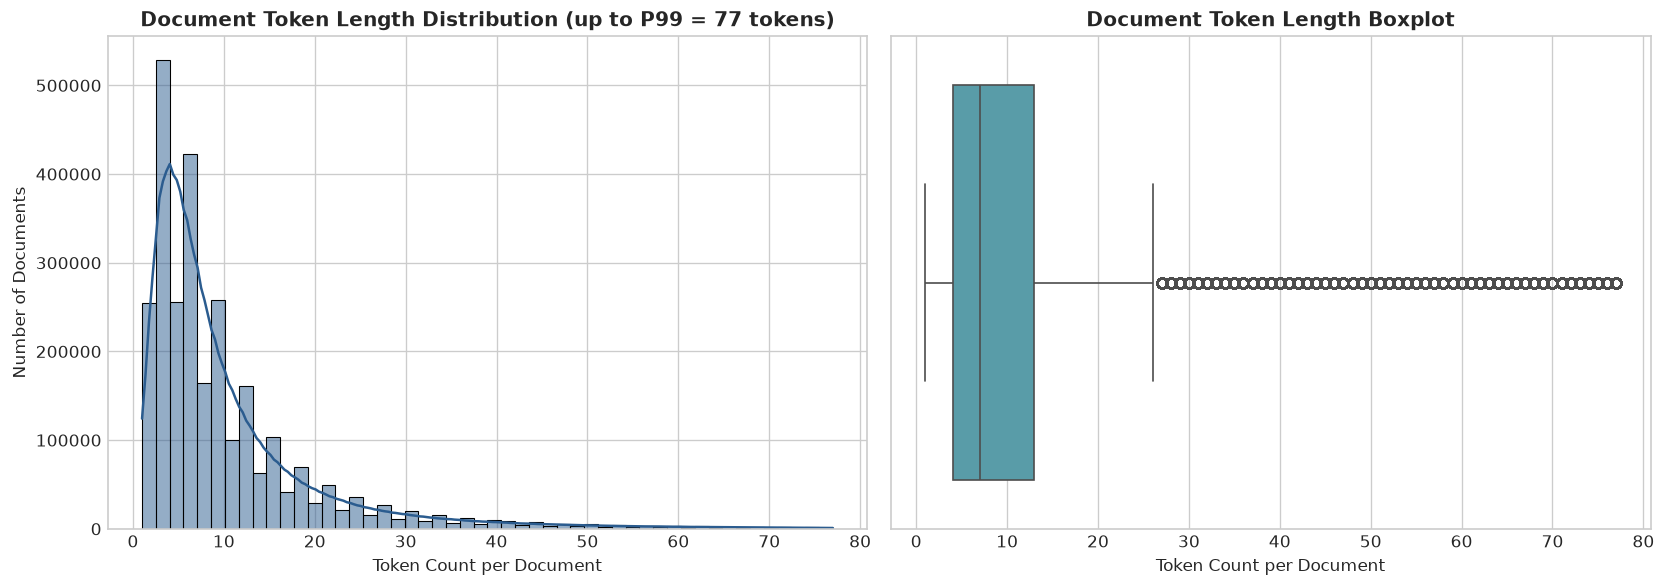

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Histogram (up to 99th percentile)
p99_val = int(percentiles[0.99])
filtered_counts = token_series[token_series <= p99_val]

sns.histplot(filtered_counts, bins=min(p99_val, 50), kde=True, color='#2b5c8f', ax=ax1)
ax1.set_title(f'Document Token Length Distribution (up to P99 = {p99_val} tokens)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Token Count per Document')
ax1.set_ylabel('Number of Documents')

# Plot 2: Boxplot
sns.boxplot(x=filtered_counts, color='#4ca5b5', ax=ax2)
ax2.set_title('Document Token Length Boxplot', fontsize=12, fontweight='bold')
ax2.set_xlabel('Token Count per Document')

plt.tight_layout()
plt.show()


### 4.2 Script Distribution Charts

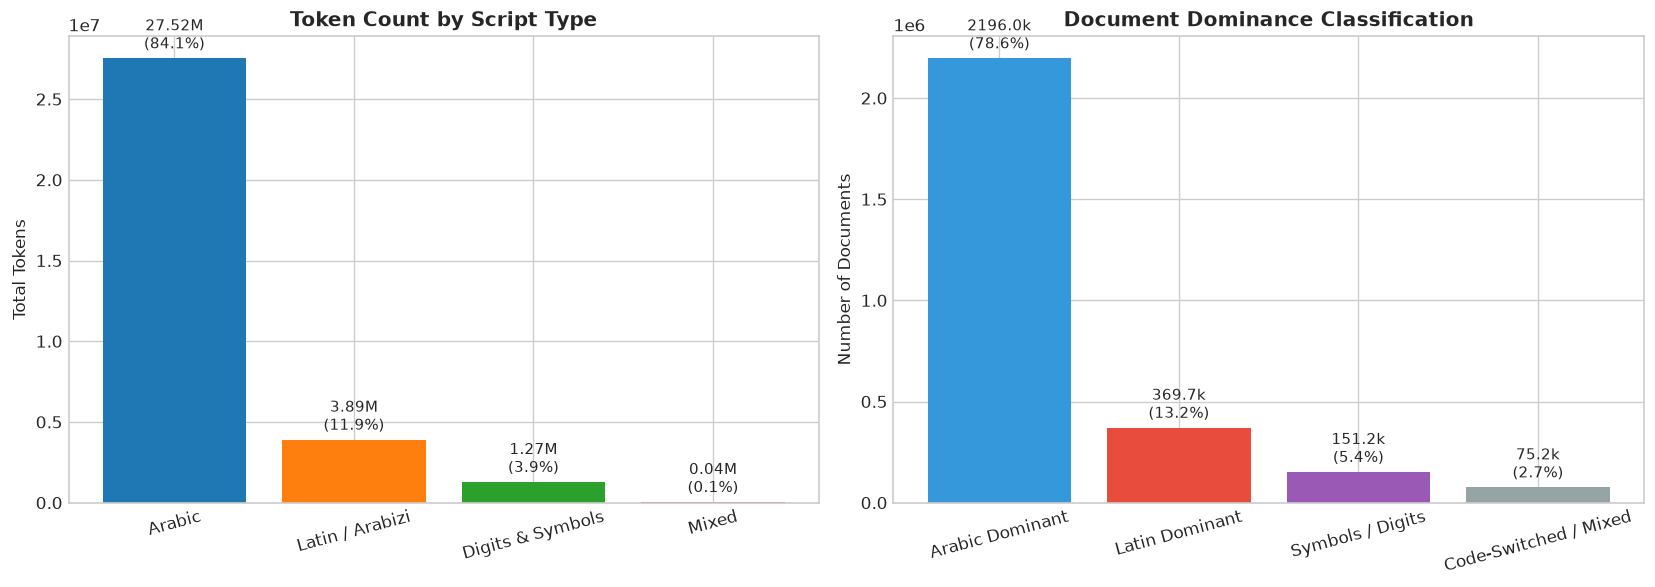

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Tokens by Script
colors1 = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
bars1 = ax1.bar(script_df['Script'], script_df['Token Count'], color=colors1[:len(script_df)])
ax1.set_title('Token Count by Script Type', fontsize=12, fontweight='bold')
ax1.set_ylabel('Total Tokens')
ax1.tick_params(axis='x', rotation=15)

for bar in bars1:
    height = bar.get_height()
    ax1.annotate(f'{height/1e6:.2f}M\n({height/total_tokens:.1%})',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3), textcoords="offset points",
                 ha='center', va='bottom', fontsize=9)

# Plot 2: Document Dominance
bars2 = ax2.bar(doc_script_df['Doc Classification'], doc_script_df['Doc Count'], color=['#3498db', '#e74c3c', '#9b59b6', '#95a5a6'])
ax2.set_title('Document Dominance Classification', fontsize=12, fontweight='bold')
ax2.set_ylabel('Number of Documents')
ax2.tick_params(axis='x', rotation=15)

for bar in bars2:
    height = bar.get_height()
    ax2.annotate(f'{height/1e3:.1f}k\n({height/total_rows:.1%})',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3), textcoords="offset points",
                 ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


## 5. Top Tokens Preview per Script

Top 15 most frequent tokens in Arabic script vs. Latin/Arabizi script:


In [7]:
top_arabic_df = pd.DataFrame(arabic_tokens_counter.most_common(15), columns=['Arabic Token', 'Count'])
top_latin_df = pd.DataFrame(latin_tokens_counter.most_common(15), columns=['Latin/Arabizi Token', 'Count'])

combined_top_df = pd.concat([top_arabic_df, top_latin_df], axis=1)
print(combined_top_df.to_string(index=False))


Arabic Token  Count Latin/Arabizi Token  Count
           و 575644           [MENTION] 203792
          في 533754                  la  41156
        الله 487177                  de  39262
          من 426429                 les  37959
         على 262514                  et  31495
         ربي 243854                  le  26689
          لي 190846                   w  26147
         انا 157634                  hh  24399
          ما 139616                   a  19498
          لا 136616                 pas  15381
          يا 129071                 des  15170
          كل 112179                pour  14872
       والله  98108                 que  14459
          ان  98053                  li  13868
         هذا  93682                  ya  13530
